# Gastrointestinal Disease Detection with Transfer Learning  
### HyperKvasir Dataset — Endoscopy Image Classification

---

## Research Context

This notebook was prepared after studying the work of  
Prof. Pekka Toivanen and Dr. Keijo Haataja from the School of Computing,  
University of Eastern Finland (UEF). Their research on wireless capsule endoscopy (WCE)  
and GI image analysis motivated me to build a smaller, classification-focused version  
of that type of pipeline using HyperKvasir.

Key references:

- Habe, Haataja, Toivanen — Frontiers in AI, 2025 (RT-DETR for WCE)  
- Habe, Haataja, Toivanen — IEEE Access, 2024 (Benchmarking object detection in WCE)  
- Habe, Haataja, Toivanen — F1000Research, 2024 (Deep learning review for GI classification)  

---

## What This Notebook Does

Wireless capsule endoscopy and standard endoscopy produce thousands of frames for a single examination.  
Reviewing all of them manually is slow and error-prone. In this notebook, I train a deep learning model  
to classify gastrointestinal findings in HyperKvasir endoscopy images. The goal is to see how far a  
carefully tuned transfer learning model can go on this dataset, and to analyse its behaviour in a way  
that is meaningful for clinical use.

Pipeline:

1. Load and explore the HyperKvasir dataset (10,662 labelled images, 23 classes).  
2. Preprocess images and apply data augmentation.  
3. Train an EfficientNet‑B3 model with transfer learning.  
4. Evaluate with precision, recall, F1-score and ROC-AUC, including per-class results.  
5. Generate Grad-CAM visualisations to inspect which image regions the model uses for its decisions.  
6. Discuss what these results might mean in a clinical context (for example, the impact of class imbalance  
   and the risk of false negatives for rare but important conditions).

Author: Muhammed Inanc | Inonu University, Turkey  
Dataset: HyperKvasir (Kaggle)  
GPU: Enable in Settings → Accelerator

## 1. Setup

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Dataset — HyperKvasir


In [2]:
# ── Find dataset root ─────────────────────────────────────────
KAGGLE_INPUT = Path('/kaggle/input')

# Try common dataset names on Kaggle
CANDIDATES = [
    'hyperkvasir/labeled-images',
    'melidsa/hyperkvasir/labeled-images',
    'hyperkvasir',
    'hyperkvasir/hyperkvasir',
]
DATA_ROOT = None
for c in CANDIDATES:
    p = KAGGLE_INPUT / c
    if p.exists() and any(p.iterdir()):
        DATA_ROOT = p
        break

if DATA_ROOT is None:
    # Fallback: Klasör içindeki resimleri ara
    for p in KAGGLE_INPUT.rglob('*.jpg'):
        DATA_ROOT = p.parent.parent
        break

if DATA_ROOT is None:
     raise FileNotFoundError("HyperKvasir dataset bulunamadı! Lütfen veri setini Kaggle'da sağ üstten 'Add Data' diyerek eklediğinizden emin olun.")

print(f'Dataset root: {DATA_ROOT}')

# ── Collect all image paths & labels ──────────────────────────
all_paths, all_labels = [], []
for class_dir in sorted(DATA_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue
    imgs = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
    all_paths.extend(imgs)
    all_labels.extend([class_dir.name] * len(imgs))

classes   = sorted(set(all_labels))
cls2idx   = {c: i for i, c in enumerate(classes)}
idx2cls   = {i: c for c, i in cls2idx.items()}
num_classes = len(classes)

print(f'Total images : {len(all_paths)}')
print(f'Classes      : {num_classes}')
print(f'Class list   : {classes[:8]} ...')

Dataset root: /kaggle/input/datasets/shafiresearch/hyperkvasir/HyperKvasir
Total images : 10662
Classes      : 23
Class list   : ['barretts', 'barretts-short-segment', 'bbps-0-1', 'bbps-2-3', 'cecum', 'dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis-a'] ...


## 3. Exploratory Data Analysis

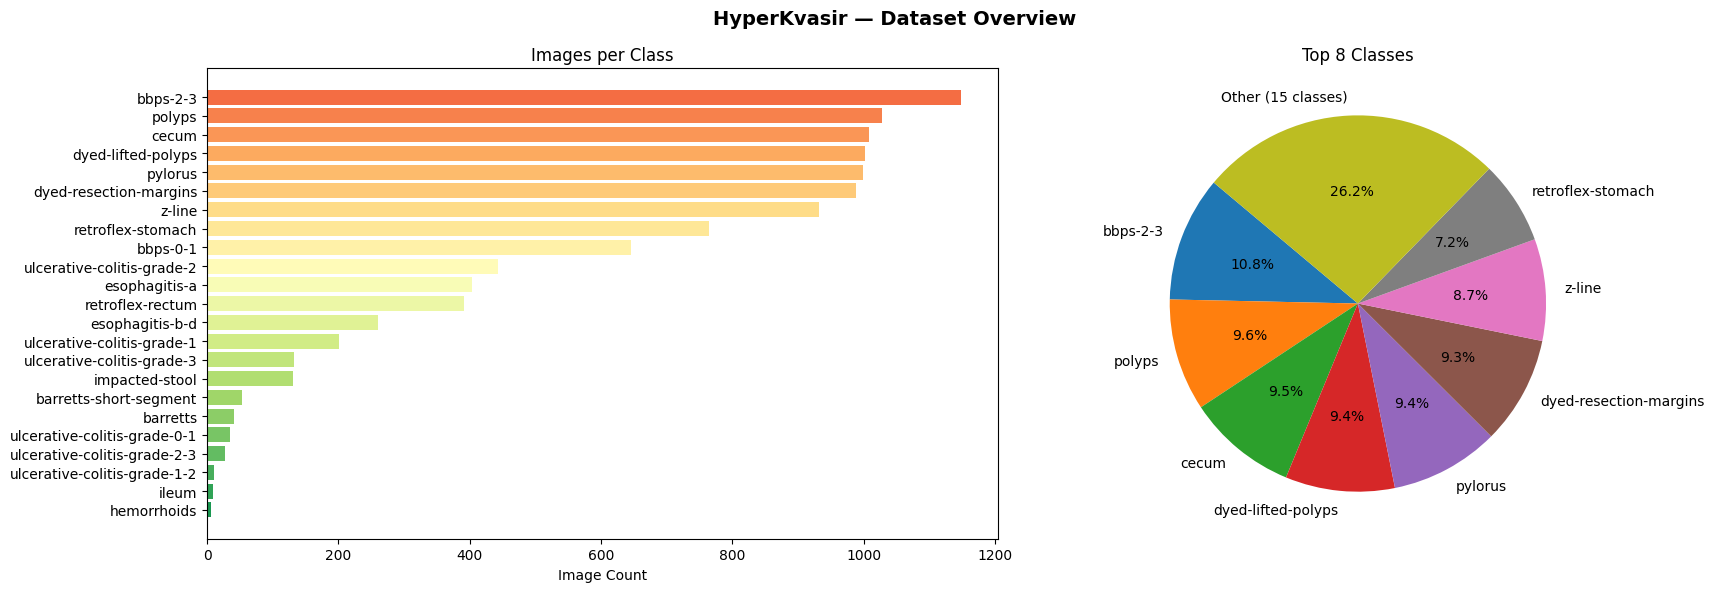

In [3]:
# ── Class distribution ────────────────────────────────────────
counts = Counter(all_labels)
df_counts = pd.DataFrame(counts.items(), columns=['Class','Count']).sort_values('Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('HyperKvasir — Dataset Overview', fontsize=14, fontweight='bold')

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_counts)))
axes[0].barh(df_counts['Class'], df_counts['Count'], color=colors)
axes[0].set_xlabel('Image Count')
axes[0].set_title('Images per Class')
axes[0].invert_yaxis()

top8 = df_counts.head(8)
rest = df_counts['Count'][8:].sum()
pie_vals   = list(top8['Count']) + [rest]
pie_labels = list(top8['Class']) + [f'Other ({len(df_counts)-8} classes)']
axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Top 8 Classes')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

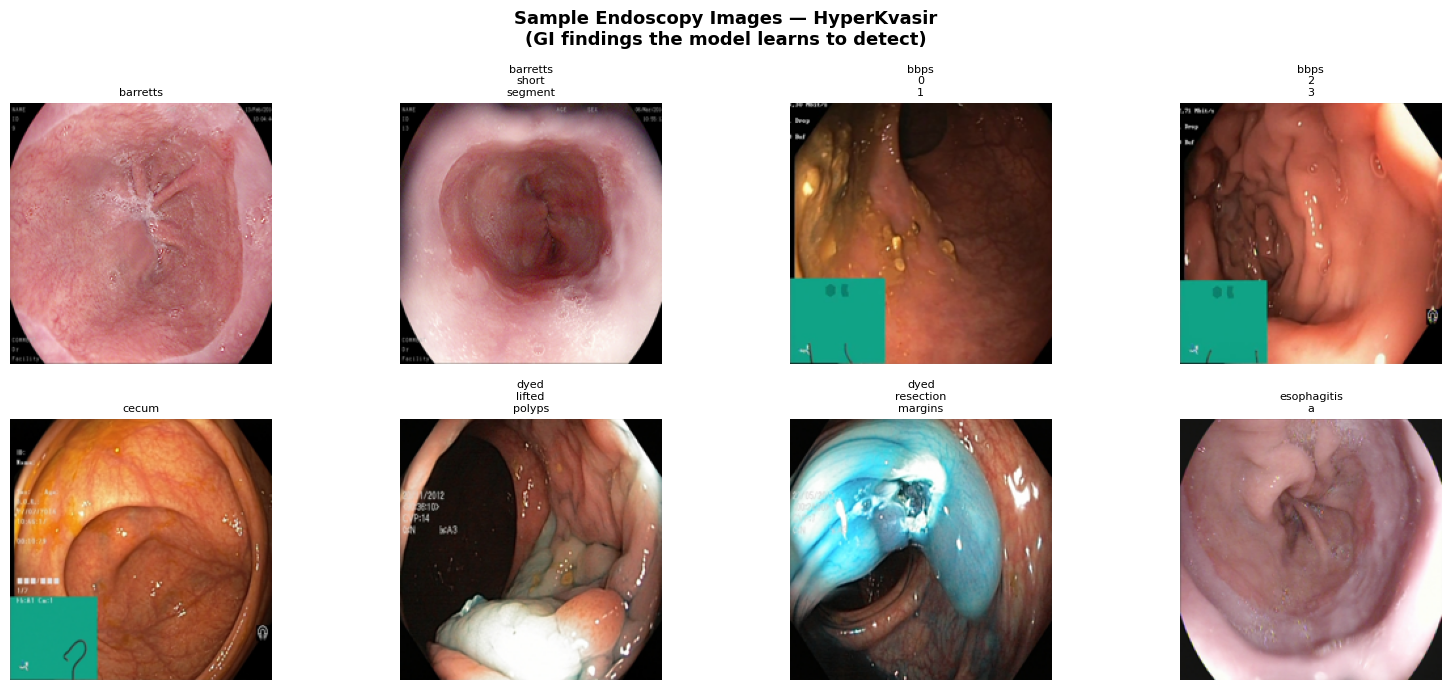

In [4]:
# ── Sample images per class ───────────────────────────────────
SHOW_CLASSES = min(8, num_classes)
fig, axes = plt.subplots(2, SHOW_CLASSES//2, figsize=(16, 7))
fig.suptitle('Sample Endoscopy Images — HyperKvasir\n(GI findings the model learns to detect)',
             fontsize=13, fontweight='bold')

for ax, cls in zip(axes.flat, classes[:SHOW_CLASSES]):
    sample = random.choice([p for p, l in zip(all_paths, all_labels) if l == cls])
    img = Image.open(sample).convert('RGB').resize((200, 200))
    ax.imshow(img)
    ax.set_title(cls.replace('-', '\n'), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing & Data Augmentation


In [5]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_tfm = T.Compose([
    T.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(0.5),
    T.RandomVerticalFlip(0.3),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

val_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])

# ── HATA GİDERİCİ 1: Nadir Sınıfları Temizleme ─────────────────
label_counts = Counter(all_labels)
MIN_SAMPLES = 10 
valid_classes = [cls for cls, count in label_counts.items() if count >= MIN_SAMPLES]

filtered_paths, filtered_labels = [], []
for p, l in zip(all_paths, all_labels):
    if l in valid_classes:
        filtered_paths.append(p)
        filtered_labels.append(l)

all_paths, all_labels = filtered_paths, filtered_labels
classes = sorted(set(all_labels))
cls2idx = {c: i for i, c in enumerate(classes)}
idx2cls = {i: c for c, i in cls2idx.items()}
num_classes = len(classes)

class KvasirDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

# ── Train / Val / Test split ─────────────────────────────────
numeric_labels = [cls2idx[l] for l in all_labels]

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_paths, numeric_labels, test_size=0.25,
    random_state=SEED, stratify=numeric_labels)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.5,
    random_state=SEED, stratify=y_tmp)

# ── HATA GİDERİCİ 2: num_workers=0 yapıldı ──────────────────
train_dl = DataLoader(KvasirDataset(X_tr, y_tr, train_tfm),
                      batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(KvasirDataset(X_val, y_val, val_tfm),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(KvasirDataset(X_te, y_te, val_tfm),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train : {len(X_tr):>5} images')
print(f'Val   : {len(X_val):>5} images')
print(f'Test  : {len(X_te):>5} images')

Train :  7985 images
Val   :  1331 images
Test  :  1331 images


## 5. Model — EfficientNet-B3 + Fine-tuning


In [6]:
class GIDetector(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b3', pretrained=True,
            num_classes=0, global_pool='avg'
        )
        if freeze_backbone:
            for name, p in self.backbone.named_parameters():
                if not any(k in name for k in ['blocks.6', 'blocks.5', 'bn2', 'conv_head']):
                    p.requires_grad = False

        feat = self.backbone.num_features   # 1536 for B3
        self.head = nn.Sequential(
            nn.Linear(feat, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

model = GIDetector(num_classes, freeze_backbone=True).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Total params     : 11,494,973
Trainable params : 9,320,371  (81.1%)


## 6. Training

In [7]:
EPOCHS   = 25
LR       = 3e-4
PATIENCE = 6

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    loss_sum, correct, total = 0., 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in tqdm(loader, leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            if training:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == lbls).sum().item()
            total    += imgs.size(0)
    return loss_sum / total, correct / total

history    = {'tl': [], 'ta': [], 'vl': [], 'va': []}
best_acc   = 0.
patience_c = 0
CKPT       = '/kaggle/working/best_model.pth'

print(f'{"Epoch":>5} {"Train Loss":>11} {"Train Acc":>10} {"Val Loss":>10} {"Val Acc":>9}')
print('─' * 52)

for epoch in range(1, EPOCHS + 1):
    tl, ta = run_epoch(model, train_dl, training=True)
    vl, va = run_epoch(model, val_dl,   training=False)
    scheduler.step()

    history['tl'].append(tl); history['ta'].append(ta)
    history['vl'].append(vl); history['va'].append(va)

    flag = ''
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), CKPT)
        patience_c = 0
        flag = '  ← best'
    else:
        patience_c += 1

    print(f'{epoch:>5} {tl:>11.4f} {ta:>10.4f} {vl:>10.4f} {va:>9.4f}{flag}')

    if patience_c >= PATIENCE:
        print(f'\nEarly stop at epoch {epoch}')
        break

print(f'\nBest Val Accuracy: {best_acc:.4f}')

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
────────────────────────────────────────────────────


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

    1      1.2214     0.7867     0.9158    0.8805  ← best


  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/42 [00:00<?, ?it/s]

    8      0.7392     0.9513     0.9014    0.8873


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]

    9      0.7256     0.9567     0.9108    0.8835

Early stop at epoch 9

Best Val Accuracy: 0.8978


## 7. Training Curves

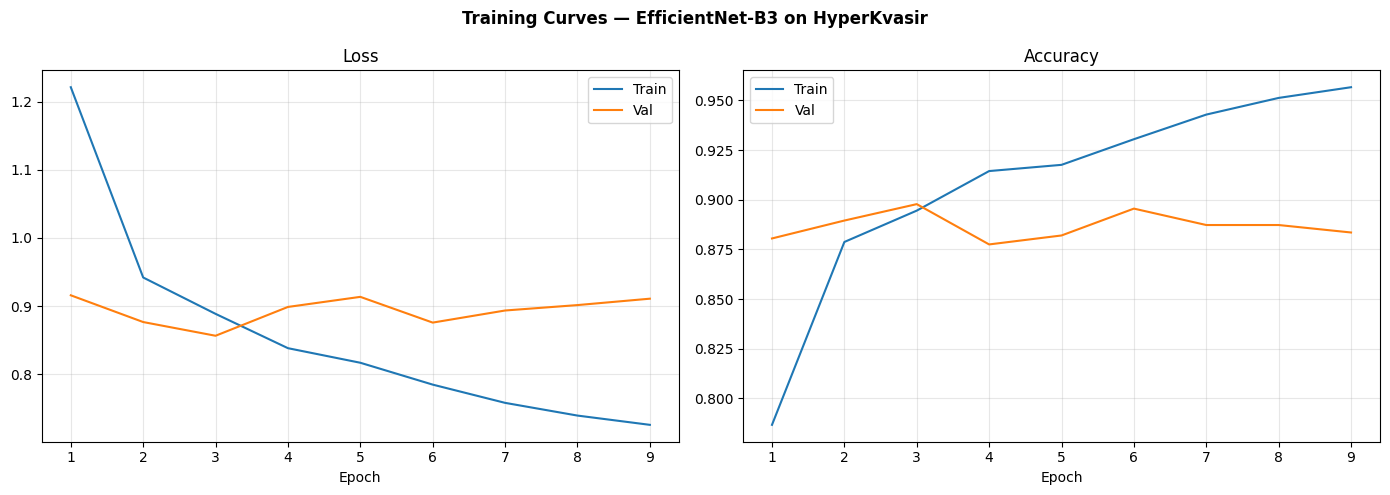

In [8]:
ep = range(1, len(history['tl']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — EfficientNet-B3 on HyperKvasir', fontweight='bold')

ax1.plot(ep, history['tl'], label='Train'); ax1.plot(ep, history['vl'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(ep, history['ta'], label='Train'); ax2.plot(ep, history['va'], label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation on Test Set

In [9]:
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()

all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in tqdm(test_dl, desc='Testing'):
        out  = model(imgs.to(DEVICE))
        prob = torch.softmax(out, dim=1).cpu().numpy()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(lbls.numpy())
        all_probs.extend(prob)

all_probs = np.array(all_probs)

print('─' * 60)
print('Classification Report')
print('─' * 60)
print(classification_report(all_true, all_preds,
                             target_names=[idx2cls[i] for i in range(num_classes)]))

Testing:   0%|          | 0/42 [00:00<?, ?it/s]

────────────────────────────────────────────────────────────
Classification Report
────────────────────────────────────────────────────────────
                              precision    recall  f1-score   support

                    barretts       0.00      0.00      0.00         5
      barretts-short-segment       0.00      0.00      0.00         6
                    bbps-0-1       0.98      0.99      0.98        80
                    bbps-2-3       0.98      0.97      0.98       144
                       cecum       0.96      1.00      0.98       126
          dyed-lifted-polyps       0.86      0.92      0.89       125
      dyed-resection-margins       0.93      0.86      0.90       124
               esophagitis-a       0.51      0.43      0.47        51
             esophagitis-b-d       0.63      0.75      0.69        32
              impacted-stool       0.82      0.82      0.82        17
                      polyps       0.88      0.99      0.93       129
               

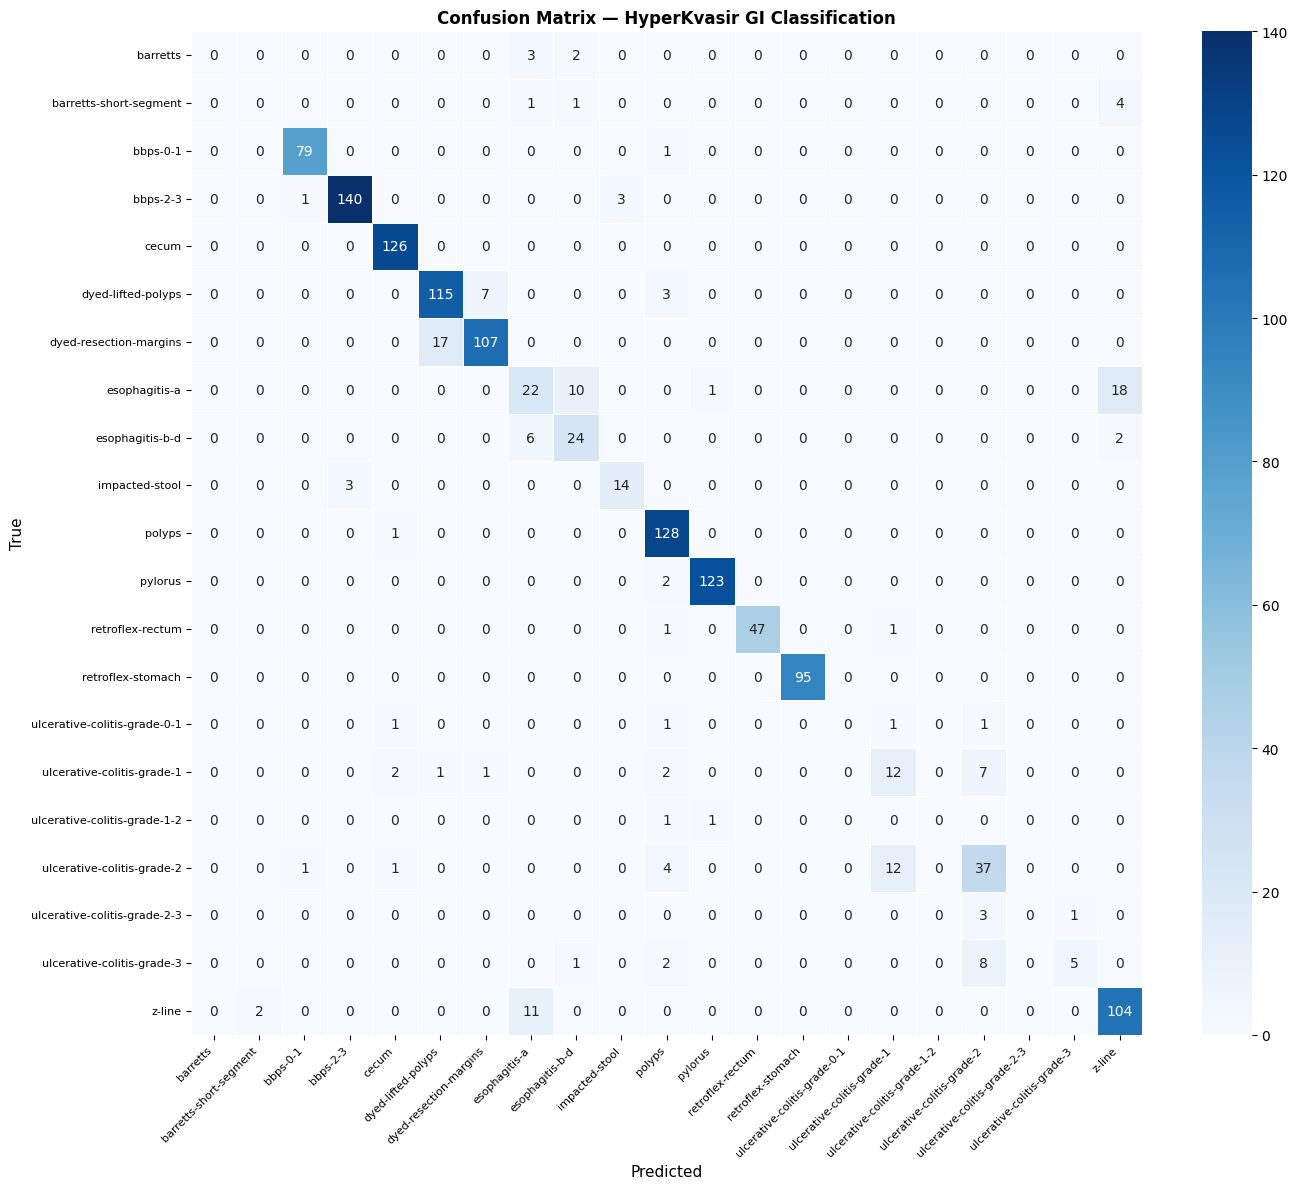

In [10]:
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[idx2cls[i] for i in range(num_classes)],
    yticklabels=[idx2cls[i] for i in range(num_classes)],
    ax=ax, linewidths=.5
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.set_title('Confusion Matrix — HyperKvasir GI Classification', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Macro ROC-AUC (OvR): 0.9668


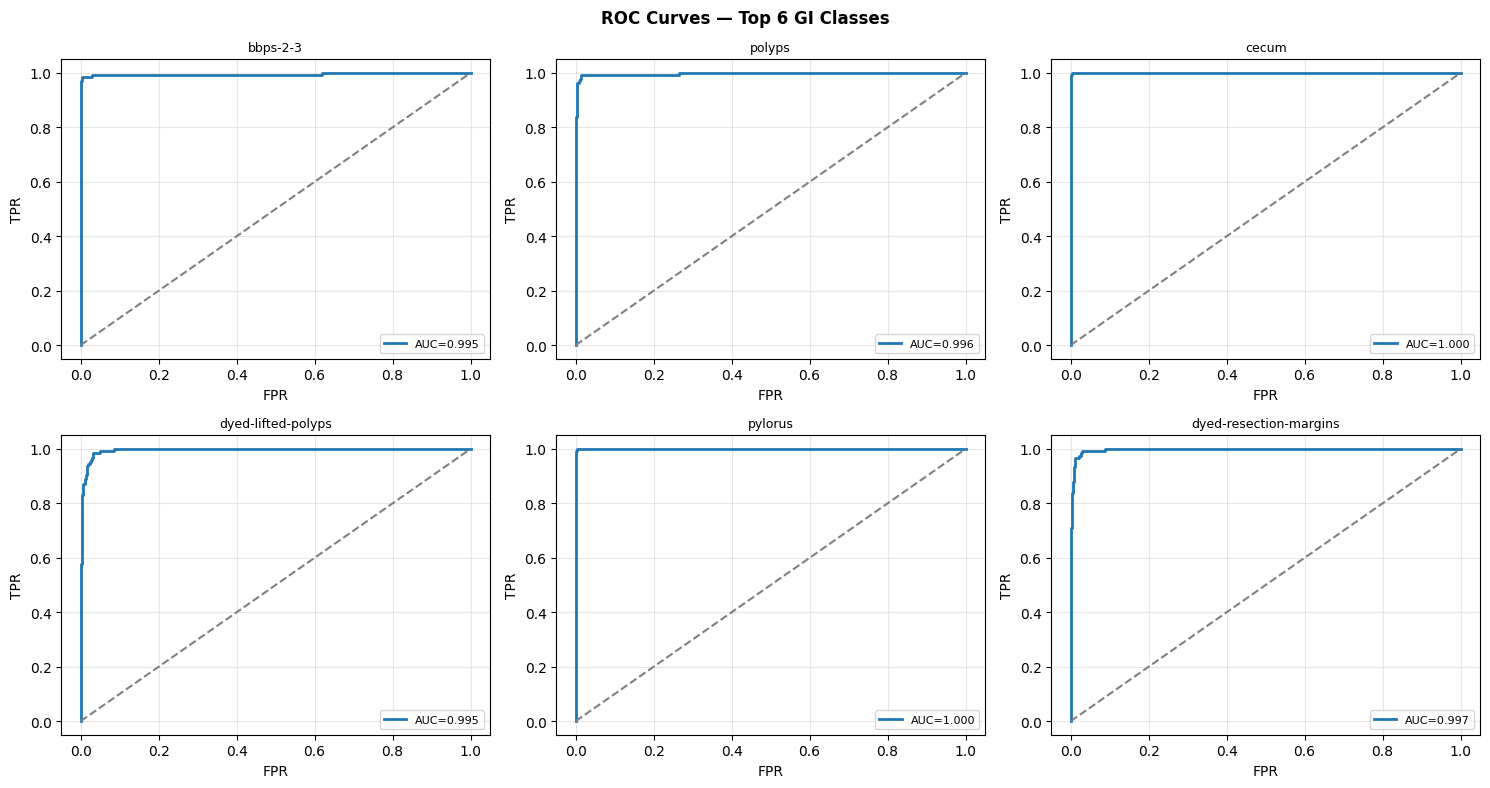

In [11]:
y_bin = label_binarize(all_true, classes=list(range(num_classes)))
macro_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')
print(f'Macro ROC-AUC (OvR): {macro_auc:.4f}')

top6 = [cls2idx[c] for c in df_counts['Class'].head(6)]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('ROC Curves — Top 6 GI Classes', fontweight='bold')

for ax, ci in zip(axes.flat, top6):
    fpr, tpr, _ = roc_curve(y_bin[:, ci], all_probs[:, ci])
    auc_i = roc_auc_score(y_bin[:, ci], all_probs[:, ci])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_i:.3f}')
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_title(idx2cls[ci], fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Grad-CAM — What Does the Model See?


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 15.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


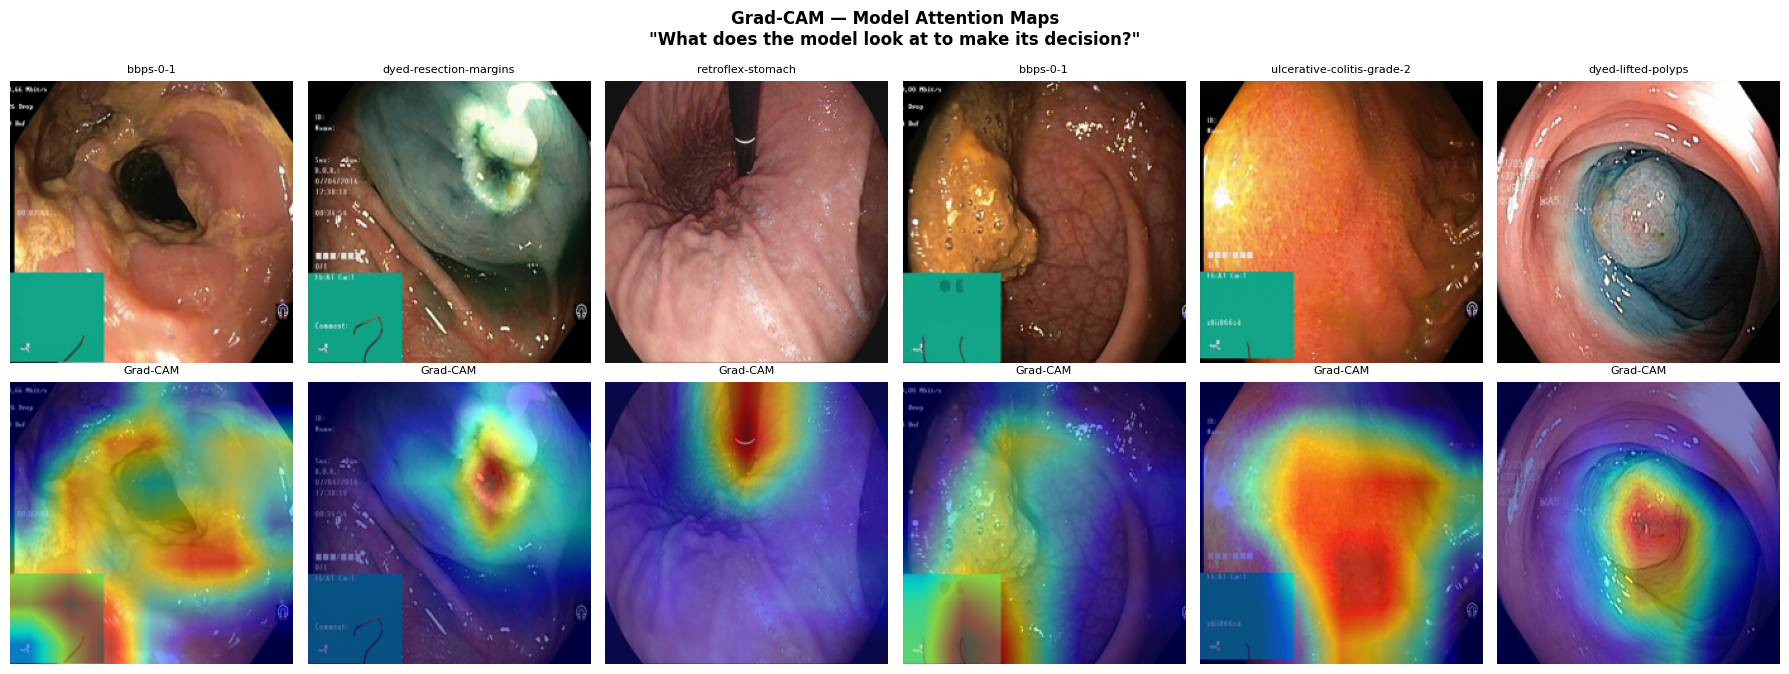

In [12]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = [model.backbone.blocks[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

samples = random.sample(list(zip(X_te, y_te)), 6)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Grad-CAM — Model Attention Maps\n'
             '"What does the model look at to make its decision?"',
             fontweight='bold', fontsize=12)

for i, (path, lbl) in enumerate(samples):
    img_pil = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np  = np.array(img_pil).astype(np.float32) / 255.
    inp     = val_tfm(img_pil).unsqueeze(0).to(DEVICE)

    gc = cam(input_tensor=inp, targets=[ClassifierOutputTarget(lbl)])
    vis = show_cam_on_image(img_np, gc[0], use_rgb=True)

    axes[0][i].imshow(img_np)
    axes[0][i].set_title(idx2cls[lbl], fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(vis)
    axes[1][i].set_title('Grad-CAM', fontsize=8)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Results Summary

In [13]:
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(all_true, all_preds)
f1  = f1_score(all_true, all_preds, average='macro')

print('━' * 55)
print('  RESULTS SUMMARY')
print('━' * 55)
print(f'  Model            : EfficientNet-B3 (Transfer Learning)')
print(f'  Dataset          : HyperKvasir ({len(all_paths)} images, {num_classes} classes)')
print(f'  Test Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Macro F1 Score   : {f1:.4f}')
print(f'  Macro ROC-AUC    : {macro_auc:.4f}')
print(f'  Best Val Acc     : {best_acc:.4f}')
print('━' * 55)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESULTS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model            : EfficientNet-B3 (Transfer Learning)
  Dataset          : HyperKvasir (10647 images, 21 classes)
  Test Accuracy    : 0.8850  (88.50%)
  Macro F1 Score   : 0.6210
  Macro ROC-AUC    : 0.9668
  Best Val Acc     : 0.8978
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
